# Performance Measures: Adjusting the threshold, ROC curve, and model comparison

In [1]:
from sklearn.datasets import fetch_openml

# as_frame=False to receive NumPy arrays instead of a Pandas DataFrame
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

# MNIST match is coming up: 60,000 for training, 10,000 for testing
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Tags to boolean: True if it is a 5
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [2]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [3]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import numpy as np

# Decision scores by cross-validation (not predictions, but the raw scores)
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

# Precision/recall for all possible thresholds
# For each threshold[i], we obtain precision[i] and recall[i].
# As the threshold increases, precision tends to increase and recall tends to decrease.

# The precision and recall you would obtain at each possible threshold.
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# We recovered the 90% accuracy threshold (where we left off in the previous notebook)
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

3370.0194991439557

## 1. New Scikit-Learn 1.5 Classes for Adjusting the Threshold

In the previous notebook, we changed the threshold **manually**:

```python
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
```

That works, but it's manual: you have to store the `y_scores`, remember to use `>=`, etc. Since **Scikit-Learn 1.5**, there are two classes that package this idea into an object that behaves like a normal classifier.

### 1.1 `FixedThresholdClassifier` (you set the threshold)

It's a **wrapper**: you take your classifier and tell it what threshold to use. From there your `predict()` applies that threshold automatically.

A subtlety about the **value** of the threshold:
- If the model has `predict_proba()` → the threshold is between **0 and 1** (default 0.5).
- If the model uses `decision_function()` (like the SGD) → the threshold is a **decision score** comparable to that output (default 0).

Since the SGD uses `decision_function()`, we directly pass it our `threshold_for_90_precision`.

In [4]:
from sklearn.model_selection import FixedThresholdClassifier

# We wrap the SGD and set our 90% accuracy threshold.
# response_method="decision_function" because the SGD doesn't have predict_probability.
sgd_90 = FixedThresholdClassifier(
    sgd_clf,
    threshold=threshold_for_90_precision,
    response_method="decision_function"
)
sgd_90.fit(X_train, y_train_5)

# Now .predict() applies the threshold for us: no more manual y_scores.
y_pred_fixed = sgd_90.predict(X_train)
y_pred_fixed[:10]

array([False, False, False, False, False, False, False, False, False,
       False])

In [5]:
from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_train_5, y_pred_fixed))
print("Recall:   ", recall_score(y_train_5, y_pred_fixed))

Precision: 0.9506477483035164
Recall:    0.5685297915513743


### 1.2 `TunedThresholdClassifierCV` (it finds the threshold automatically)

This is the **automatic** version. Instead of you calculating the threshold, this class uses **k-fold cross-validation** to test many thresholds and keep the best one according to the **metric you choose**.

- By default, it maximizes the *balanced accuracy* (the average recall of each class), useful with unbalanced classes.

- But you can ask it for another metric. Here, we ask it to find the threshold that maximizes the **F1**.

> Note: this retrains with CV, so it takes a little longer.

In [6]:
from sklearn.model_selection import TunedThresholdClassifierCV

# We ask you to find only the optimal threshold for "F1"
tuned = TunedThresholdClassifierCV(
    SGDClassifier(random_state=42),
    scoring="f1",
    cv=3
)
tuned.fit(X_train, y_train_5)

# The threshold it automatically chose:
print("Chosen threshold:", tuned.best_threshold_)

Chosen threshold: -1978.1595928759489


In [7]:
y_pred_tuned = tuned.predict(X_train)
print("Precision:", precision_score(y_train_5, y_pred_tuned))
print("Recall:   ", recall_score(y_train_5, y_pred_tuned))

Precision: 0.3878253066108286
Recall:    0.9566500645637336


## 2. The ROC Curve

The ROC curve is another tool for evaluating binary classifiers, **very similar** to the Precision/Recall curve, but with different axes. Instead of plotting precision vs. recall, it plots:

- **Y-axis → TPR** (True Positive Rate) = *recall* by another name. Out of the 5 actual positives, how many do you correctly identify?
- **X-axis → FPR** (False Positive Rate) = out of the actual **non-5s**, how many do you incorrectly classify as 5?

The formulas are:

$$TPR = \frac{TP}{TP + FN} \qquad FPR = \frac{FP}{FP + TN}$$

You'll often encounter different terms referring to the same concepts: recall = sensitivity = TPR; specificity = TNR; and **FPR = 1 − specificity**. To use the ROC curve, you only need to remember that a **high TPR is good** and a **low FPR is good**.

In [8]:
from sklearn.metrics import roc_curve

# Calculate TPR and FPR for many different thresholds
fpr, tpr, thresholds_roc = roc_curve(y_train_5, y_scores)

Marcamos el punto que corresponde al umbral del 90% de precision. Ojo: aquí los umbrales vienen en orden **decreciente**, así que usamos `<=` (no `>=`) para encontrar el índice.

In [9]:
# Index of the point that corresponds to our 90% accuracy threshold
idx_for_threshold_at_90 = (thresholds_roc <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]
print("At that point -> FPR:", round(fpr_90, 4), "| TPR (recall):", round(tpr_90, 4))

At that point -> FPR: 0.0053 | TPR (recall): 0.48


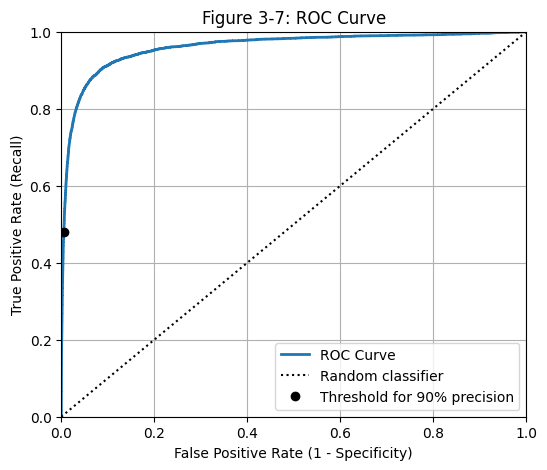

In [10]:
# At the threshold that gives me 90% accuracy, my model detects 48% of the real 5s (TPR) and incorrectly marks only 0.53% of those that are not as 5s (FPR).
# With such a demanding cutoff, I'm very accurate when I say "it's a 5" (90% accuracy), but in return, I miss more than half of the 5s (recall 48%).
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
plt.plot([0, 1], [0, 1], "k:", label="Random classifier")  # reference diagonal
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Figure 3-7: ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.show()

The trade-off appears again:
**trade-off**: the higher the recall (TPR), the more false positives (FPR) you produce. The dotted diagonal represents a classifier that guesses randomly; a good model moves away from it towards the **top left corner**.

## 3. AUC (Area Under the Curve)

One way to summarize the entire ROC curve with **a single number** is to measure the area under it (AUC):

- Perfect classifier → **AUC = 1**
- Random classifier → **AUC = 0.5**

In [11]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

0.9604938554008616

In [12]:
from sklearn.metrics import roc_auc_score, average_precision_score

n_pos = (y_train_5 == 1).sum()
n_neg = (y_train_5 == 0).sum()

print(
    f"Positives (5): {n_pos}  |  Negatives (non-5): {n_neg}  "
    f"({100 * n_pos / (n_pos + n_neg):.1f}% are 5s)"
)
print(f"ROC AUC:           {roc_auc_score(y_train_5, y_scores):.4f}   <- looks excellent")
print(f"Average Precision: {average_precision_score(y_train_5, y_scores):.4f}   <- the reality")

Positives (5): 5421  |  Negatives (non-5): 54579  (9.0% are 5s)
ROC AUC:           0.9605   <- looks excellent
Average Precision: 0.8100   <- the reality


The 5s almost always score higher than the non-5s. In 96 out of 100 comparisons, the 5s outperform the non-5s. This yields approximately 0.96, which **seems** excellent... but be careful: it's misleading because there are very few 5s compared to non-5s (unbalanced classes). With many negatives, the denominator of the FPR is enormous, and the ROC looks impressive even if the model is flawed.

**Rule of thumb for choosing a curve:**
- Rare positive class, or if false positives are more important to you → use the **PR** (precision/recall) curve.
- In all other cases → use the **ROC** curve.

Here, since the 5s are rare, the PR curve is more accurate and clearly shows that there is still room for improvement.

## 4. A second model: RandomForestClassifier

Now we train a Random Forest to **compare** it with the SGD. The technical detail: the Random Forest **doesn't have** `decision_function()`. But it does have `predict_proba()`, which returns **probabilities** for each class. We use the probability of the positive class as if it were the score.

In [13]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

# We request probabilities by cross-validation
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

# First two rows: each row sums to 1 -> [P(no-5), P(5)]
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

The first row `[0.11, 0.89]` means: 11% chance of being non-5, 89% chance of being 5 → the model believes it **is** a 5. The second row `[0.99, 0.01]` → it is almost certainly **not** a 5.

**Note (book warning):** These are *estimated* probabilities, not actual ones. They may underestimate or overestimate. If you need reliable probabilities (medical diagnosis, fraud, financial risk), there is `CalibratedClassifierCV` to calibrate them.

In [14]:
# The second column is P(positive class) -> we use it as the score
y_scores_forest = y_probas_forest[:, 1]

precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)

## 5. Comparing PR Curves: SGD vs. Random Forest

We plotted both PR curves side-by-side. The one closest to the **top right corner** (high accuracy AND high recall at the same time) is the best.

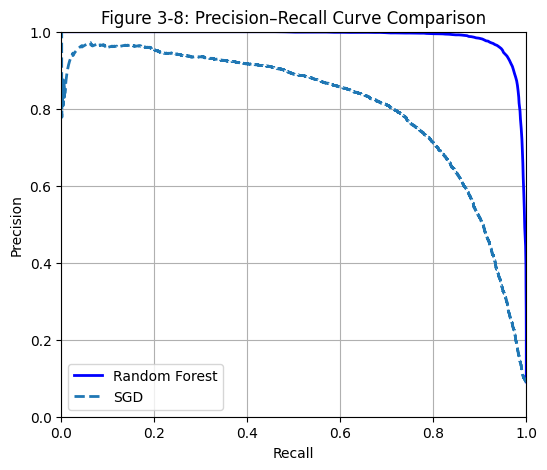

In [15]:
plt.figure(figsize=(6, 5))
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Figure 3-8: Precision–Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.show()

The Random Forest curve is **much closer** to the top right corner → it's clearly better. Let's confirm this with the numbers.

In [16]:
from sklearn.metrics import f1_score

# Predictions using a 0.5 threshold (positive probability >= 50%)
y_train_pred_forest = (y_scores_forest >= 0.5)

print("F1 score: ", f1_score(y_train_5, y_train_pred_forest))
print("ROC AUC:  ", roc_auc_score(y_train_5, y_scores_forest))
print("Precision:", precision_score(y_train_5, y_train_pred_forest))
print("Recall:   ", recall_score(y_train_5, y_train_pred_forest))

F1 score:  0.9274509803921569
ROC AUC:   0.9983436731328145
Precision: 0.9897468089558485
Recall:    0.8725327430363402


The Random Forest achieves **~99% accuracy and ~87% recall**, compared to the SGD's poor 48% recall when forced to 90% accuracy. It delivers high accuracy **without** sacrificing so much recall: it's the better of the two.